# 数据结构实验：二叉树与图

本实验实现二叉树和图（有向图、无向图）的基本操作，并通过可视化界面演示。


二叉树操作测试：
高度: 4
先序: [50, 30, 20, 15, 25, 40, 35, 45, 70, 60, 55, 65, 80, 75, 85]
中序: [15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]
后序: [15, 25, 20, 35, 45, 40, 30, 55, 65, 60, 75, 85, 80, 70, 50]


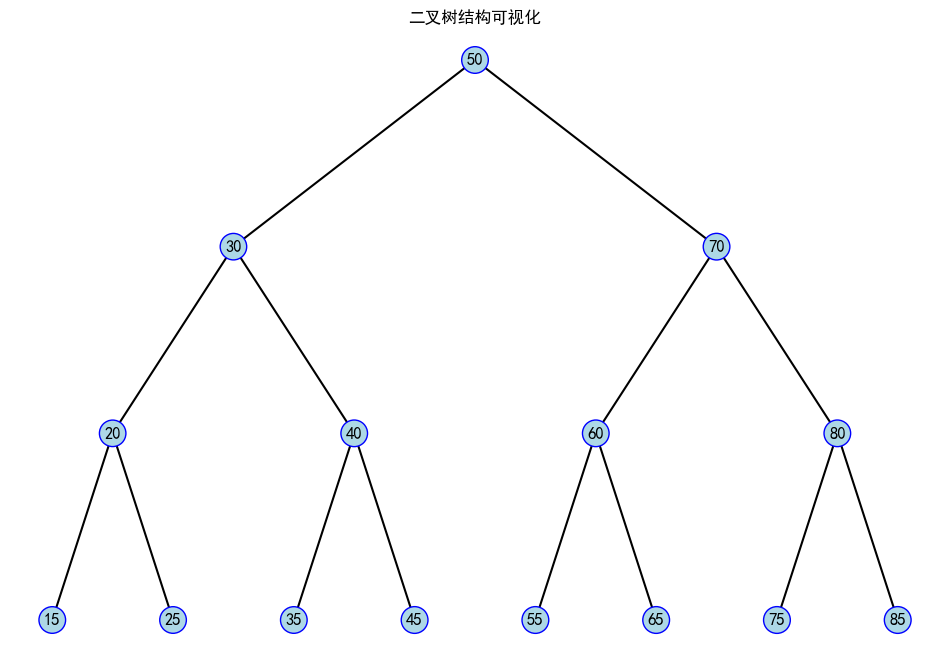

In [1]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import numpy as np

class TreeNode:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

class BinaryTree:
    def __init__(self):
        self.root = None

    def insert(self, value):
        if self.root is None:
            self.root = TreeNode(value)
        else:
            self._insert(self.root, value)

    def _insert(self, node, value):
        if value < node.value:
            if node.left is None:
                node.left = TreeNode(value)
            else:
                self._insert(node.left, value)
        else:
            if node.right is None:
                node.right = TreeNode(value)
            else:
                self._insert(node.right, value)

    def preorder(self):
        return self._preorder_recursive(self.root)

    def _preorder_recursive(self, node):
        if node is None:
            return []
        res = [node.value]
        res.extend(self._preorder_recursive(node.left))
        res.extend(self._preorder_recursive(node.right))
        return res

    def inorder(self):
        return self._inorder_recursive(self.root)

    def _inorder_recursive(self, node):
        if node is None:
            return []
        res = []
        res.extend(self._inorder_recursive(node.left))
        res.append(node.value)
        res.extend(self._inorder_recursive(node.right))
        return res

    def postorder(self):
        return self._postorder_recursive(self.root)

    def _postorder_recursive(self, node):
        if node is None:
            return []
        res = []
        res.extend(self._postorder_recursive(node.left))
        res.extend(self._postorder_recursive(node.right))
        res.append(node.value)
        return res

    def height(self):
        return self._height_recursive(self.root)

    def _height_recursive(self, node):
        if node is None:
            return 0
        return 1 + max(self._height_recursive(node.left), self._height_recursive(node.right))

    def draw(self):
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.set_axis_off()

        def _draw(node, x, y, x_offset):
            if node is None:
                return
            plt.text(x, y, str(node.value), fontsize=12,
                    bbox=dict(facecolor='lightblue', edgecolor='blue', boxstyle='circle'),
                    ha='center', va='center')
            if node.left:
                plt.plot([x, x - x_offset], [y, y - 1], 'k-')
                _draw(node.left, x - x_offset, y - 1, x_offset / 2)
            if node.right:
                plt.plot([x, x + x_offset], [y, y - 1], 'k-')
                _draw(node.right, x + x_offset, y - 1, x_offset / 2)

        _draw(self.root, 0, self.height(), 2 ** (self.height() - 1))
        plt.title('二叉树结构可视化')
        plt.show()

bt = BinaryTree()
for val in [50, 30, 70, 20, 40, 60, 80, 15, 25, 35, 45, 55, 65, 75, 85]:
    bt.insert(val)

print("二叉树操作测试：")
print(f"高度: {bt.height()}")
print(f"先序: {bt.preorder()}")
print(f"中序: {bt.inorder()}")
print(f"后序: {bt.postorder()}")
bt.draw()



无向图操作测试：
顶点: {'E', 'C', 'G', 'F', 'B', 'A', 'D'}
DFS: ['A', 'B', 'D', 'E', 'C', 'F', 'G']
BFS: ['A', 'B', 'C', 'D', 'E', 'F', 'G']


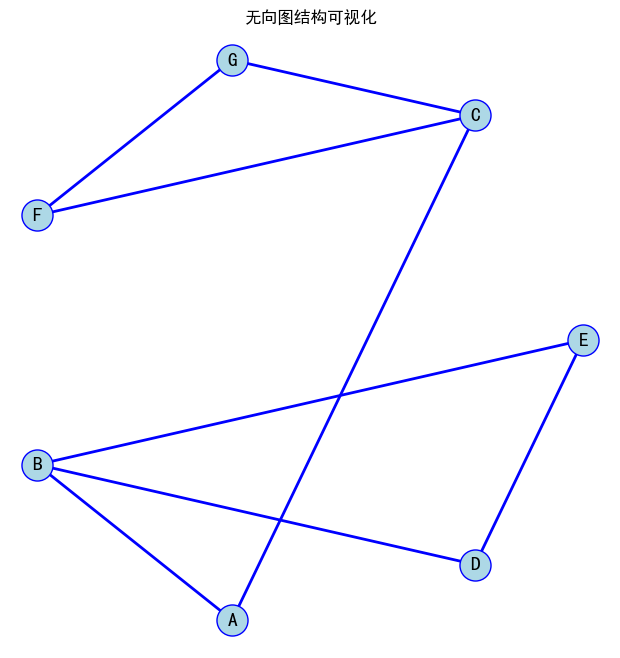

In [2]:
class UndirectedGraph:
    def __init__(self):
        self.vertices = set()
        self.adj = {}

    def add_vertex(self, v):
        if v not in self.vertices:
            self.vertices.add(v)
            self.adj[v] = []

    def add_edge(self, v1, v2):
        self.add_vertex(v1)
        self.add_vertex(v2)
        if v2 not in self.adj[v1]:
            self.adj[v1].append(v2)
        if v1 not in self.adj[v2]:
            self.adj[v2].append(v1)

    def dfs(self, start, visited=None):
        if visited is None:
            visited = set()
        visited.add(start)
        res = [start]
        for n in sorted(self.adj[start]):
            if n not in visited:
                res.extend(self.dfs(n, visited))
        return res

    def bfs(self, start):
        visited, queue = set(), [start]
        visited.add(start)
        res = []
        while queue:
            v = queue.pop(0)
            res.append(v)
            for n in sorted(self.adj[v]):
                if n not in visited:
                    visited.add(n)
                    queue.append(n)
        return res

    def draw(self):
        fig, ax = plt.subplots(figsize=(10, 8))
        vs = list(self.vertices)
        pos = {v: (np.cos(i * 2 * np.pi / len(vs)), np.sin(i * 2 * np.pi / len(vs))) for i, v in enumerate(vs)}

        for v1 in self.adj:
            for v2 in self.adj[v1]:
                if vs.index(v1) < vs.index(v2):
                    plt.plot([pos[v1][0], pos[v2][0]], [pos[v1][1], pos[v2][1]], 'b-', linewidth=2)

        for v, (x, y) in pos.items():
            plt.scatter(x, y, s=500, c='lightblue', edgecolors='blue', zorder=5)
            plt.text(x, y, str(v), fontsize=14, ha='center', va='center', zorder=6)

        ax.set_aspect('equal')
        plt.title('无向图结构可视化')
        plt.axis('off')
        plt.show()

ug = UndirectedGraph()
for e in [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'F'), ('C', 'G'), ('D', 'E'), ('F', 'G')]:
    ug.add_edge(*e)

print("无向图操作测试：")
print(f"顶点: {ug.vertices}")
print(f"DFS: {ug.dfs('A')}")
print(f"BFS: {ug.bfs('A')}")
ug.draw()


有向图操作测试：
顶点: {'E', 'C', 'G', 'F', 'B', 'A', 'D'}
DFS: ['A', 'B', 'D', 'E', 'G', 'C', 'F']
BFS: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
拓扑排序: ['A', 'B', 'C', 'D', 'F', 'E', 'G']


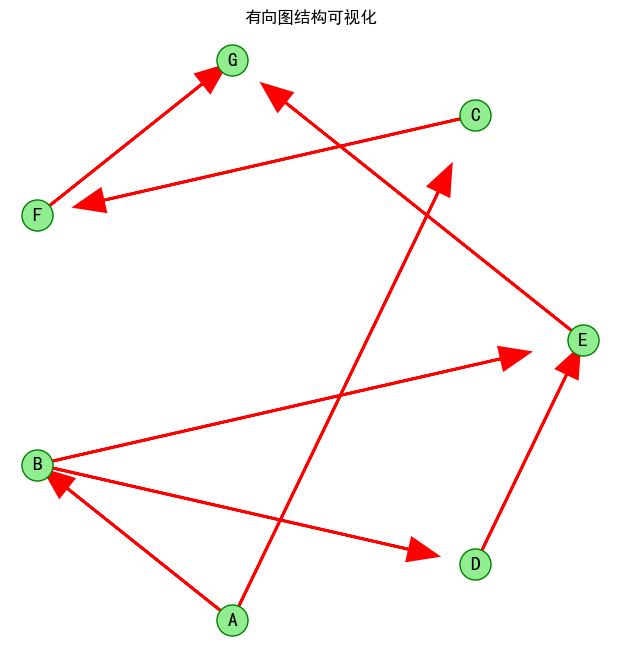

In [3]:
class DirectedGraph:
    def __init__(self):
        self.vertices = set()
        self.adj = {}

    def add_vertex(self, v):
        if v not in self.vertices:
            self.vertices.add(v)
            self.adj[v] = []

    def add_edge(self, v_from, v_to):
        self.add_vertex(v_from)
        self.add_vertex(v_to)
        if v_to not in self.adj[v_from]:
            self.adj[v_from].append(v_to)

    def dfs(self, start, visited=None):
        if visited is None:
            visited = set()
        visited.add(start)
        res = [start]
        for n in sorted(self.adj[start]):
            if n not in visited:
                res.extend(self.dfs(n, visited))
        return res

    def bfs(self, start):
        visited, queue = set(), [start]
        visited.add(start)
        res = []
        while queue:
            v = queue.pop(0)
            res.append(v)
            for n in sorted(self.adj[v]):
                if n not in visited:
                    visited.add(n)
                    queue.append(n)
        return res

    def topological_sort(self):
        in_deg = {v: sum(1 for vs in self.adj.values() if v in vs) for v in self.vertices}
        queue = [v for v in self.vertices if in_deg[v] == 0]
        res = []
        while queue:
            v = queue.pop(0)
            res.append(v)
            for n in self.adj[v]:
                in_deg[n] -= 1
                if in_deg[n] == 0:
                    queue.append(n)
        return res if len(res) == len(self.vertices) else None

    def draw(self):
        fig, ax = plt.subplots(figsize=(10, 8))
        vs = list(self.vertices)
        pos = {v: (np.cos(i * 2 * np.pi / len(vs)), np.sin(i * 2 * np.pi / len(vs))) for i, v in enumerate(vs)}

        for v_from in self.adj:
            for v_to in self.adj[v_from]:
                x1, y1 = pos[v_from]
                x2, y2 = pos[v_to]
                dx, dy = x2 - x1, y2 - y1
                length = np.sqrt(dx ** 2 + dy ** 2)
                if length > 0:
                    ax.arrow(x1, y1, dx * 0.85, dy * 0.85,
                             head_width=0.08, head_length=0.1,
                             fc='red', ec='red', linewidth=2)

        for v, (x, y) in pos.items():
            plt.scatter(x, y, s=500, c='lightgreen', edgecolors='green', zorder=5)
            plt.text(x, y, str(v), fontsize=14, ha='center', va='center', zorder=6)

        ax.set_aspect('equal')
        plt.title('有向图结构可视化')
        plt.axis('off')
        plt.show()

dg = DirectedGraph()
for e in [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'F'), ('D', 'E'), ('E', 'G'), ('F', 'G')]:
    dg.add_edge(*e)

print("有向图操作测试：")
print(f"顶点: {dg.vertices}")
print(f"DFS: {dg.dfs('A')}")
print(f"BFS: {dg.bfs('A')}")
print(f"拓扑排序: {dg.topological_sort()}")
dg.draw()
